# Statistics Practice - Sales Data

This notebook covers a few basic statistics topics using a small sales dataset:
- Hypothesis testing
- Distribution fitting with scipy
- A/B test simulation
- Correlation matrix heatmap

I am keeping the examples simple so it is easy to understand what is happening.

In [ ]:
#install required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

np.random.seed(42) #reproducibility

## 1. Create some sales data

In [ ]:
# A small example dataset
sales = np.array([
    48, 52, 51, 49, 55, 58, 53, 50, 47, 54,
    56, 52, 49, 51, 57, 60, 55, 53, 50, 59,
    61, 56, 54, 52, 58, 63, 57, 55, 51, 60,
    62, 59, 56, 54, 61, 64, 58, 57, 53, 62
])

print("Number of days:", len(sales))
print("Average sales:", round(sales.mean(), 2))
print("Standard deviation:", round(sales.std(ddof=1), 2))

Number of days: 40
Average sales: 55.3
Standard deviation: 4.42


## 2. Hypothesis testing on sales data

Suppose the company normally expects around **55 sales per day**.

We want to check whether the average sales in our sample is actually different from 55.

- **H0 (null hypothesis):** average sales = 55
- **H1 (alternative hypothesis):** average sales is not 55

We can use a one-sample t-test here.

In [ ]:
expected_sales = 55

t_stat, p_value = stats.ttest_1samp(sales, expected_sales)

print("t-statistic:", round(t_stat, 3))
print("p-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Reject H0. The average looks significantly different from 55.")
else:
    print("Result: We do not have enough evidence to reject H0.")

t-statistic: 0.43
p-value: 0.6698
Result: We do not have enough evidence to reject H0.


### A quick look at the sales

A histogram helps us see how the sales values are spread.

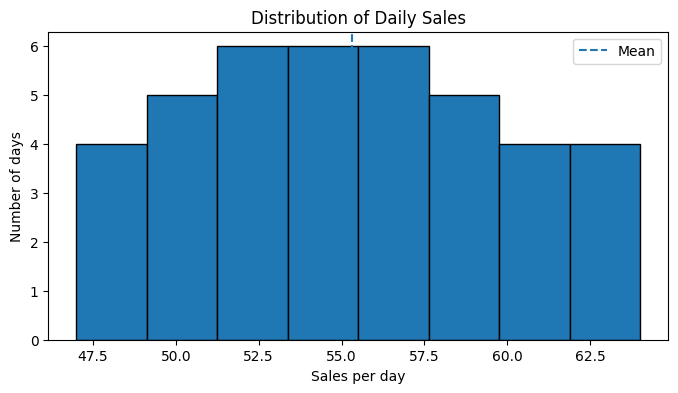

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(sales, bins=8, edgecolor='black')
plt.axvline(sales.mean(), linestyle='--', label='Mean')
plt.xlabel('Sales per day')
plt.ylabel('Number of days')
plt.title('Distribution of Daily Sales')
plt.legend()
plt.show()

## 3. Distribution fitting with scipy

Now let's see whether a normal distribution is a reasonable fit for the sales data.

We first estimate the mean and standard deviation from the data, then compare the normal curve with the histogram.

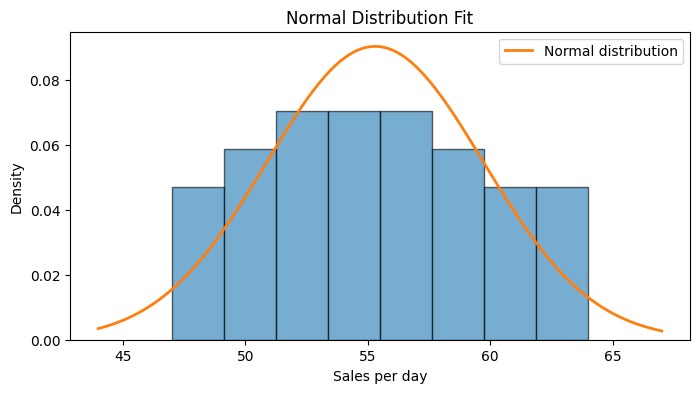

Fitted mean: 55.3
Fitted standard deviation: 4.42


In [ ]:
mean = sales.mean()
std = sales.std(ddof=1)

x = np.linspace(sales.min() - 3, sales.max() + 3, 200)
normal_curve = stats.norm.pdf(x, mean, std)

plt.figure(figsize=(8, 4))
plt.hist(sales, bins=8, density=True, alpha=0.6, edgecolor='black')
plt.plot(x, normal_curve, linewidth=2, label='Normal distribution')
plt.xlabel('Sales per day')
plt.ylabel('Density')
plt.title('Normal Distribution Fit')
plt.legend()
plt.show()

print("Fitted mean:", round(mean, 2))
print("Fitted standard deviation:", round(std, 2))

In [ ]:
# A simple goodness-of-fit check using the Kolmogorov-Smirnov test
ks_stat, ks_p = stats.kstest(sales, 'norm', args=(mean, std))

print("KS statistic:", round(ks_stat, 3))
print("KS p-value:", round(ks_p, 4))
print("This gives us a rough idea of how well a normal distribution fits the sample.")

KS statistic: 0.074
KS p-value: 0.9702
This gives us a rough idea of how well a normal distribution fits the sample.


## 4. A/B test simulation

Imagine an online store is testing two versions of a button.

- **A:** old button
- **B:** new button

Let's simulate visitors and conversions. Then we can check whether the difference between A and B is statistically significant.

In [ ]:
n = 1000

# Simulated conversion results: 0 = no conversion, 1 = conversion
group_a = np.random.binomial(1, 0.10, n)
group_b = np.random.binomial(1, 0.13, n)

conversion_a = group_a.mean()
conversion_b = group_b.mean()

print("A conversion rate:", round(conversion_a * 100, 2), "%")
print("B conversion rate:", round(conversion_b * 100, 2), "%")
print("Difference:", round((conversion_b - conversion_a) * 100, 2), "percentage points")

A conversion rate: 10.0 %
B conversion rate: 13.1 %
Difference: 3.1 percentage points


### Test the A/B result

For a simple example, we can use a two-proportion z-test. The null hypothesis says that both versions have the same conversion rate.

In [ ]:
success_a = group_a.sum()
success_b = group_b.sum()

p_pool = (success_a + success_b) / (2 * n)
se = np.sqrt(p_pool * (1 - p_pool) * (2 / n))

z = (conversion_b - conversion_a) / se
p_value_ab = 2 * (1 - stats.norm.cdf(abs(z)))

print("z-statistic:", round(z, 3))
print("p-value:", round(p_value_ab, 4))

if p_value_ab < 0.05:
    print("Result: The difference between A and B is statistically significant.")
else:
    print("Result: We do not have enough evidence that A and B are different.")

z-statistic: 2.169
p-value: 0.0301
Result: The difference between A and B is statistically significant.


## 5. Correlation matrix heatmap

Finally, let's make a small dataset with sales-related variables.

Correlation tells us how strongly two numeric variables move together. A heatmap makes these relationships easier to see.

In [ ]:
df = pd.DataFrame({
    'Sales': sales,
    'Advertising': sales * 0.8 + np.random.normal(0, 8, len(sales)),
    'Website_Visits': sales * 12 + np.random.normal(0, 45, len(sales)),
    'Discount': np.random.uniform(5, 25, len(sales)),
    'Returns': np.random.poisson(3, len(sales))
})

df.head()

,Sales,Advertising,Website_Visits,Discount,Returns
0,48,31.376139,595.645191,20.865227,4
1,52,34.984957,664.677068,11.335234,2
2,51,38.988169,505.668040,22.143585,3
3,49,42.138924,542.562118,23.122865,1
4,55,51.308677,687.861942,10.538090,4


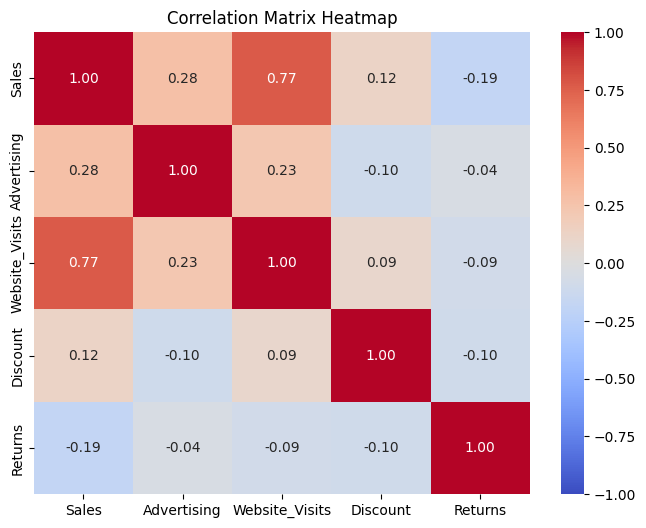

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Final observations

From this small practice:

1. **Hypothesis testing** helps us decide whether a sample gives enough evidence against a claim.
2. **Distribution fitting** helps us understand whether our data looks similar to a known distribution such as the normal distribution.
3. **A/B testing** helps compare two versions of a product or feature using data.
4. **Correlation** helps us see relationships between numeric variables, although correlation does not mean causation.

These are simple examples, but the same ideas are used in real data analysis projects.